In [1]:
from pathlib import Path
import sys

path = Path.cwd().resolve().parent
sys.path.append(str(path))

In [2]:
from app.core.llm import llm
from app.core.embeddings import embedding_model

In [3]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage, AIMessage
from langgraph.prebuilt import ToolNode, tools_condition
from app.tools import TOOLS
from langchain_community.tools import tool
from typing import Annotated
from langchain.tools import InjectedState
from typing import Annotated, List
from langgraph.graph import add_messages
from typing import TypedDict, Literal
from langchain_core.vectorstores import InMemoryVectorStore

In [4]:
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    user_query: str
    updated_query: str
    documents: List[Document]
    loop_count: int
    grade_result: Literal['yes', 'no']

In [5]:
class GradeDocuments(BaseModel):
    binary_score: Literal['yes', 'no'] = Field(
        description="Are the documents relevant to answering the user's base question? 'yes' or 'no'"
    )

In [6]:
system_message = """
        You are an expert workflow router. Analyze the chat history and the latest message to decide whether to query the 'query_pdf_database' tool or reply directly.

        Review these examples to guide your routing architecture:

        Example 1 (Casual/Meta Intent -> Direct Reply):
        - History: [Agent explains a complex budget step]
        - User: "Can you summarize that in one sentence for my manager?"
        - Decision: Do NOT use tools. Generate a direct summary from history.

        Example 2 (Ambiguous Context Intent -> Tool Use):
        - History: User asks about Project Mercury -> Agent returns budget stats.
        - User: "Are there any timeline constraints on that?"
        - Decision: Use 'query_pdf_database' because "that" refers back to the Project Mercury context.

        Example 3 (Factual Intent -> Tool Use):
        - User: "What is our current spending cap on infrastructure for 2026?"
        - Decision: Use 'query_pdf_database' to extract specific numbers.

        Rules:
        1. Default to tool usage if the question cannot be definitively answered using ONLY the text already present in the chat history.
        2. Ensure search queries passed to the tool are focused entirely on key nouns and entities, stripping out conversational filler.
    """

In [7]:
vector_store = InMemoryVectorStore(embedding_model)
vector_store.add_documents([
    Document(page_content="Project Mercury's total budget for fiscal year 2026 is capped at $4.2 million.", metadata={"source": "mercury_plan.pdf"}),
    Document(page_content="The primary launch window for the Mercury satellite opens on October 12, 2026.", metadata={"source": "mercury_plan.pdf"})
])
vector_retriever = vector_store.as_retriever(search_kwargs={'k': 1})

In [8]:
class RetrieverInput(BaseModel):
    query: str = Field(description="The search query to look up in the document database")

@tool(args_schema=RetrieverInput, response_format='content_and_artifact')
def retriever(query: str, state: Annotated[AgentState, InjectedState]):
    """Queries the internal corporate PDF database to fetch reference material on projects, timelines, and budgets."""
    
    docs = vector_retriever.invoke(query)
    retrieved_text = "\n\n".join([docs.page_content for docs in state['documents']])

    
    return (retrieved_text, docs)

In [9]:
def agent(state: AgentState):

    llm_with_tools = llm.bind_tools([retriever])

    response = llm_with_tools.invoke(state['messages'])
    
    return {
        "messages": [response]
    }

In [10]:
def sync_artifacts_node(state: AgentState):
    """Safely extracts tool artifacts and assigns them to the state channel."""

    last_tool_message = next((msg for msg in reversed(state["messages"]) if msg.type == "tool"), None)
    
    if last_tool_message:
        artifacts = getattr(last_tool_message, "artifact", []) or []
        return {"documents": artifacts}
    
    return {}

In [11]:
def grade_docs(state: AgentState):  

    grade_llm = llm.with_structured_output(GradeDocuments)
    retrieved_text = "\n\n".join([docs.page_content for docs in state['documents']])
    
    grade_prompt = [
        SystemMessage("""You are a strict data auditor. Evaluate whether the provided text context contains
            semantically useful information to answer the user's question. Return a binary score structure: 'yes' or 'no'."""
        ),
        HumanMessage(f"""User Query: {state['user_query']}
            Retrieved Text: {retrieved_text}"""
        )
    ]
    assesment = grade_llm.invoke(grade_prompt)
    return {
        "grade_result": assesment.binary_score
    }

In [12]:
def query_transformer(state: AgentState):

    retrieved_text = "\n\n".join([docs.page_content for docs in state['documents']])

    transform_prompt = [
        SystemMessage(
            "You are an expert search string optimizer. Your job is to rewrite a failed search query into a completely "
            "new, alternative search string.\n\n"
            "CRITICAL RULES:\n"
            "1. Do NOT reuse the words, phrases, or structure from the FAILED_PREVIOUS_QUERY.\n"
            "2. Focus purely on target noun entities, alternative synonyms, or broader categorization keywords related to the ORIGINAL_USER_QUESTION.\n"
            "3. Do not include conversational fluff, instructions, or label prefixes.\n"
            "4. Return ONLY the raw optimized string line."
        ),
        HumanMessage(
            f"ORIGINAL_USER_QUESTION: {state['user_query']}\n"
            f"FAILED_PREVIOUS_QUERY: {state.get('updated_query', '')}\n"
            f"REJECTED_IRRELEVANT_CONTEXT:\n{retrieved_text}\n\n"
            "TASK: Provide a completely revised, DIFFERENT alternative search query string based on the rules above."
        )
    ]
    new_query = llm.invoke(transform_prompt).content.strip()
    
    state_msg = AIMessage(
        content="Refining my documentation lookup to isolate data...",
        tool_calls=[{"name": "retriever", "args": {'query': new_query}, "id": "retry_call_id_" + str(state.get("loop_count", 0))}]
    )
    return {
        'messages': [state_msg],
        'updated_query': new_query,
        'loop_count': state.get("loop_count", 0) + 1,
    }

In [13]:
def generator(state: AgentState):

    retrieved_text = "\n\n".join([docs.page_content for docs in state['documents']])
    prompt = [
        SystemMessage("""You are a professional research agent. Synthesize a clean answer to the user prompt.
            You must base your answer ONLY on the provided Context text block. If the retrived text does not 
            contain the answer for the user query then you just say that you can't find any usefull information
            from the provided documents."""
        ),
        HumanMessage(f"""User Query: {state['user_query']},
            Retrieved text: {retrieved_text}"""
        )
    ]
    response = llm.invoke(prompt)

    return {
        "messages": [response]
    }

In [14]:
def route_intent(state: AgentState):
    last_msg = state['messages'][-1]
    if last_msg.tool_calls:
        return 'tools'
    return 'end'

In [15]:
def route_generator(state: AgentState):
    if state['grade_result'] == 'yes':
        return 'generator'
    
    if state['loop_count'] >= 2:
        return 'generator'
    
    return 'query_transform'

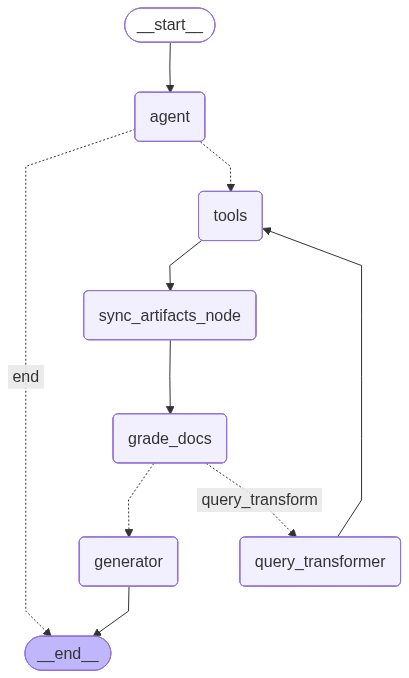

In [16]:
builder = StateGraph(AgentState)

builder.add_node('agent', agent)
builder.add_node('tools', ToolNode([retriever]))
builder.add_node('sync_artifacts_node', sync_artifacts_node)
builder.add_node('grade_docs', grade_docs)
builder.add_node('query_transformer', query_transformer)
builder.add_node('generator', generator)

builder.add_edge(START, 'agent')
builder.add_conditional_edges(
    'agent', route_intent,
    {
        'tools': 'tools',
        'end': END
    }
)
builder.add_edge('tools', 'sync_artifacts_node')
builder.add_edge('sync_artifacts_node', 'grade_docs')
builder.add_conditional_edges(
    'grade_docs',
    route_generator,
    {
        'generator': 'generator',
        'query_transform': 'query_transformer'
    }
)
builder.add_edge('query_transformer', 'tools')
builder.add_edge('generator', END)

graph = builder.compile()

graph

In [17]:
message = "Who is sahrukh khan?"
state = {
    'messages': [
        SystemMessage(system_message),
        HumanMessage(message),
    ],
    'user_query': message,
    'documents': [],
    'loop_count': 0,
}

In [22]:
from app.render_messages.streaming.transformer import transform_events_v2


async def test_streaming_pipeline():

    initial_state = {
        "messages": [HumanMessage(content="hello")],
        "user_query": "",
        "updated_query": "",
        "documents": [],
        "loop_count": 0,
        "grade_result": "no"
    }

    print("--- STARTING WORKFLOW STREAM ---\n")

    async for event in graph.astream_events(initial_state, version='v2'):
        transformed = transform_events_v2(event)
        if transformed:
            print(transformed)

    print('\n', initial_state['documents'])
    print("\n\n--- WORKFLOW COMPLETE ---")

await test_streaming_pipeline()

--- STARTING WORKFLOW STREAM ---

type='token' content='Hello'
type='token' content='!'
type='token' content=' How'
type='token' content=' can'
type='token' content=' I'
type='token' content=' help'
type='token' content=' you'
type='token' content=' today'
type='token' content='?'

 []


--- WORKFLOW COMPLETE ---


In [19]:
state['messages']

[SystemMessage(content='\n        You are an expert workflow router. Analyze the chat history and the latest message to decide whether to query the \'query_pdf_database\' tool or reply directly.\n\n        Review these examples to guide your routing architecture:\n\n        Example 1 (Casual/Meta Intent -> Direct Reply):\n        - History: [Agent explains a complex budget step]\n        - User: "Can you summarize that in one sentence for my manager?"\n        - Decision: Do NOT use tools. Generate a direct summary from history.\n\n        Example 2 (Ambiguous Context Intent -> Tool Use):\n        - History: User asks about Project Mercury -> Agent returns budget stats.\n        - User: "Are there any timeline constraints on that?"\n        - Decision: Use \'query_pdf_database\' because "that" refers back to the Project Mercury context.\n\n        Example 3 (Factual Intent -> Tool Use):\n        - User: "What is our current spending cap on infrastructure for 2026?"\n        - Decision:

In [20]:
state

{'messages': [SystemMessage(content='\n        You are an expert workflow router. Analyze the chat history and the latest message to decide whether to query the \'query_pdf_database\' tool or reply directly.\n\n        Review these examples to guide your routing architecture:\n\n        Example 1 (Casual/Meta Intent -> Direct Reply):\n        - History: [Agent explains a complex budget step]\n        - User: "Can you summarize that in one sentence for my manager?"\n        - Decision: Do NOT use tools. Generate a direct summary from history.\n\n        Example 2 (Ambiguous Context Intent -> Tool Use):\n        - History: User asks about Project Mercury -> Agent returns budget stats.\n        - User: "Are there any timeline constraints on that?"\n        - Decision: Use \'query_pdf_database\' because "that" refers back to the Project Mercury context.\n\n        Example 3 (Factual Intent -> Tool Use):\n        - User: "What is our current spending cap on infrastructure for 2026?"\n      